In [1]:
# Versión para garantizar reproducibilidad en Colab
!pip install scikeras==0.13.0 scikit-learn==1.4.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 46.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.43 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.


In [2]:
# Librerías
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (roc_auc_score, f1_score, recall_score,
                              precision_score, make_scorer, balanced_accuracy_score, accuracy_score)

from xgboost import XGBClassifier
from keras.models import load_model

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, SGD
from scikeras.wrappers import KerasClassifier
import matplotlib.gridspec as gridspec

# Montamos Drive y fijamos ruta base
from google.colab import drive
drive.mount('/content/drive')

RUTA_BASE = "/content/drive/MyDrive/"

# Semillas reproducibles
import os, random
os.environ["PYTHONHASHSEED"] = "42"
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

Mounted at /content/drive


Cargamos los datasets necesarios: particiones train UNDER y test. Para el SVM también guardamos una submuestra de 150 instancias porque KernelExplainer es muy lento sobre el train completo

In [3]:
# Cargamos datasets
x_train_UNDER = pd.read_csv(RUTA_BASE + "x_train_UNDER.csv")
x_test_final  = pd.read_csv(RUTA_BASE + "x_test_final.csv")
y_train_UNDER = pd.read_csv(RUTA_BASE + "y_train_UNDER.csv").squeeze()
y_test_final  = pd.read_csv(RUTA_BASE + "y_test_final.csv").squeeze()

# XGBoost y NN se entrenaron con etiquetas 0/1
y_train_under_xgb = (y_train_UNDER == "Sí").astype(int)
y_test_bin        = (y_test_final  == "Sí").astype(int)

# Submuestra para SHAP del SVM
x_train_small = x_train_UNDER.sample(150, random_state=42)

Cargamos los mejores modelos de Undersampling tras el entrenamiento y la validación

In [4]:
# Modelos sklearn/XGBoost del pickle + red neuronal en formato Keras
with open(RUTA_BASE + "modelos_finales.pkl", "rb") as f:
    modelos_cargados = pickle.load(f)

best_rf_under2        = modelos_cargados["rf_under"]
best_xgb_under2       = modelos_cargados["xgb_under"]
best_svm_under2       = modelos_cargados["svm_under"]
best_lr_under2        = modelos_cargados["lr_under"]
modelo_final_nn_under = load_model(RUTA_BASE + "nn_under.keras")

#SHAP

Para cada modelo, calculamos valores SHAP sobre el train UNDER y guardamos:

 - shap_values : objeto SHAP completo (beeswarm)
- shap_matrix  : matriz numpy (n_instancias × n_features) para el bootstrap
 - shap_importance : tabla con mean|SHAP| por feature, ordenada


In [5]:
import shap

# Función para devolver un dataframe con mean|SHAP| por feature
def importancia_shap(matriz_shap, columnas):
    return (
        pd.DataFrame({
            "feature":       columnas,
            "mean_abs_shap": np.abs(matriz_shap).mean(axis=0),
        })
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

##Random Forest

 97%|=================== | 773/796 [00:31<00:00]       

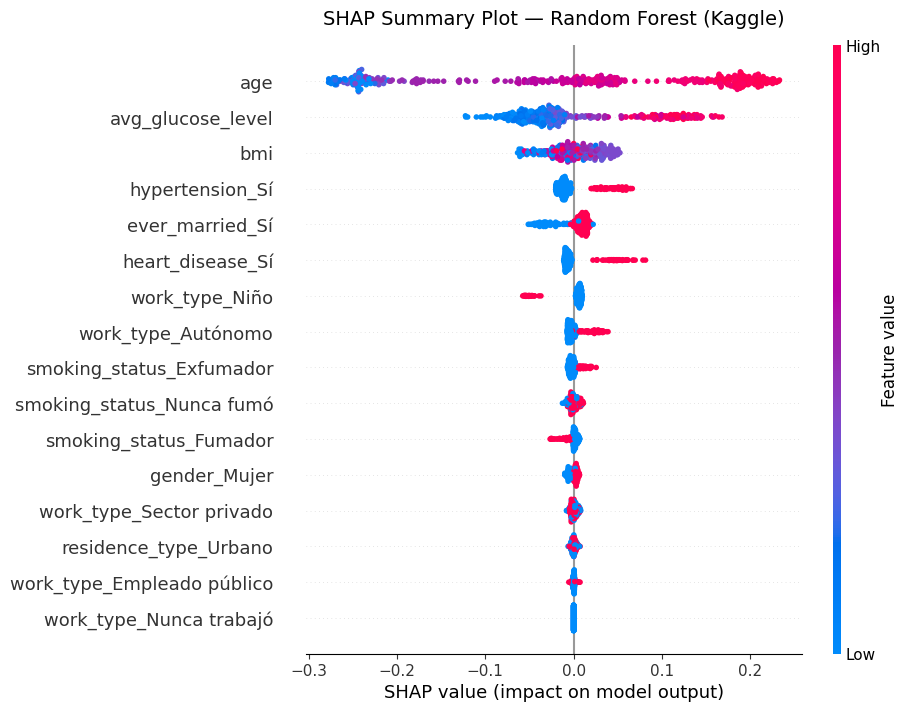

In [6]:
#Motor de explicaciones usando como referencia los datos del entrenamiento
explainer_rf   = shap.Explainer(best_rf_under2, x_train_UNDER,
                                output_names=["No Stroke", "Stroke"])
# Calculamos SHAP sobre los datos de TRAIN
shap_values_rf = explainer_rf(x_train_UNDER)
shap_matrix_rf = shap_values_rf[:, :, 1].values

#Summary plot de SHAP para RF
shap.plots.beeswarm(shap_values_rf[:, :, 1], max_display=20, show=False)
plt.title("SHAP Summary Plot — Random Forest (Kaggle)", fontsize=14, pad=15)
plt.show()

# Calculamos el SHAP medio de cada variable del modelo
shap_importance_rf = importancia_shap(shap_matrix_rf, x_train_UNDER.columns)

## XGBoost

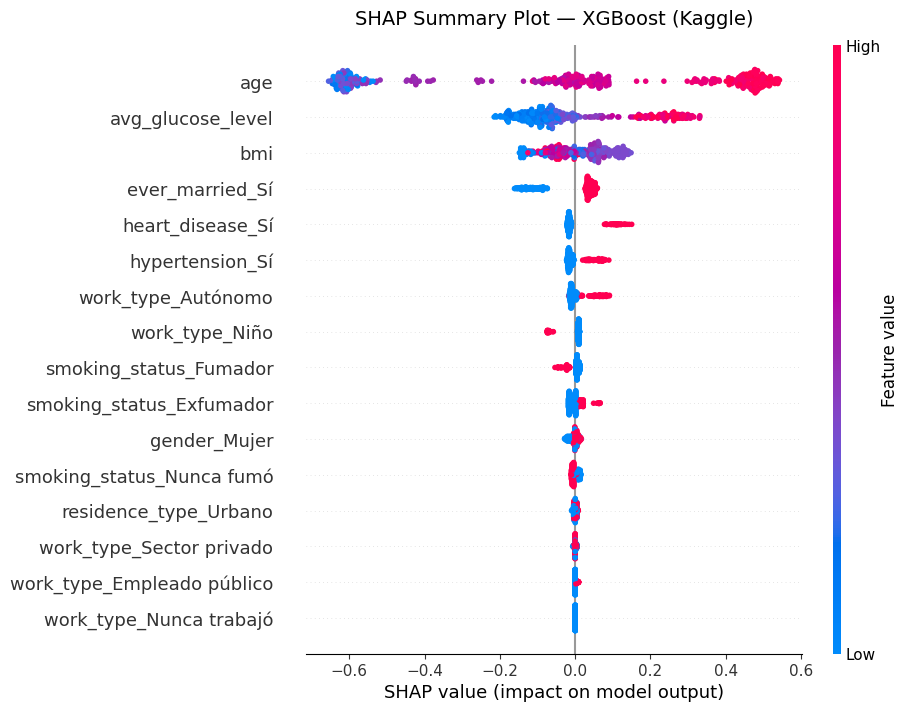

In [7]:
#Motor de explicaciones usando como referencia los datos del entrenamiento
explainer_xgb   = shap.Explainer(best_xgb_under2, x_train_UNDER,
                                 output_names=["No Stroke", "Stroke"])

#Calculamos las explicaciones para cada fila del train
shap_values_xgb = explainer_xgb(x_train_UNDER)
shap_matrix_xgb = shap_values_xgb.values

#Summary plot de SHAP para XGB
shap.plots.beeswarm(shap_values_xgb, max_display=20, show=False)
plt.title("SHAP Summary Plot — XGBoost (Kaggle)", fontsize=14, pad=15)
plt.show()

# Calculamos el SHAP medio de cada variable del modelo
shap_importance_xgb = importancia_shap(shap_matrix_xgb, x_train_UNDER.columns)

## SVM

Calculamos SHAP solo sobre 150 instancias del train (x_train_small)

  0%|          | 0/150 [00:00<?, ?it/s]

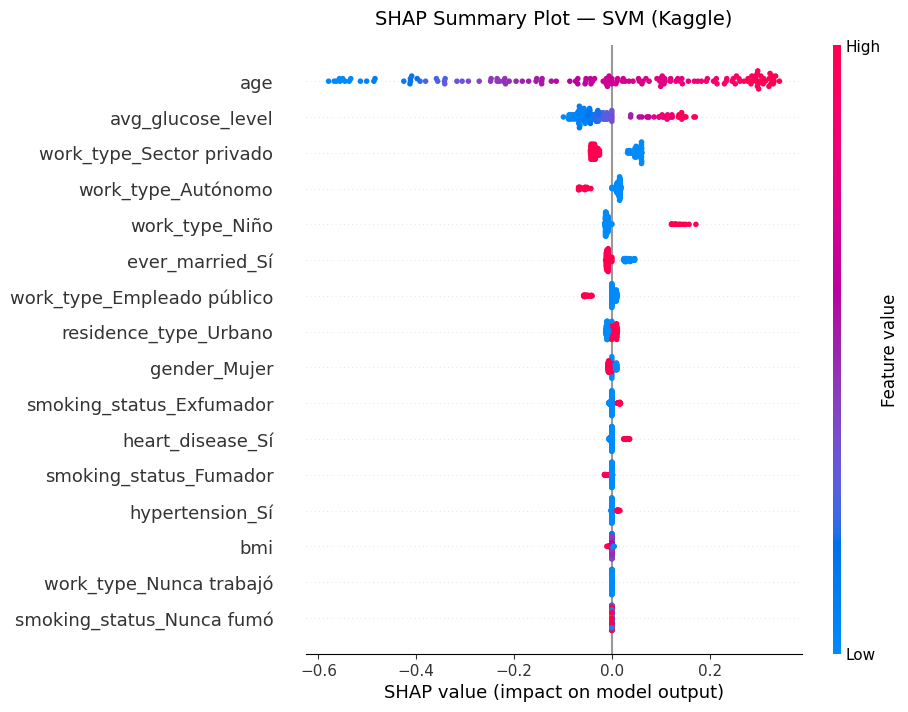

In [8]:
# Usamos subset del train para el explainer
background      = shap.kmeans(x_train_UNDER, 100)
explainer_svm   = shap.KernelExplainer(best_svm_under2.predict_proba, background)

#Extraemos los valores SHAP
shap_values_svm = explainer_svm(x_train_small)
shap_matrix_svm = shap_values_svm.values[:, :, 1]

#Summary plot de SHAP para SVM
shap.plots.beeswarm(shap_values_svm[:, :, 1], max_display=20, show=False)
plt.title("SHAP Summary Plot — SVM (Kaggle)", fontsize=14, pad=15)
plt.show()

# Calculamos el SHAP medio de cada variable del modelo
shap_importance_svm = importancia_shap(shap_matrix_svm, x_train_small.columns)

## Regresión Logística

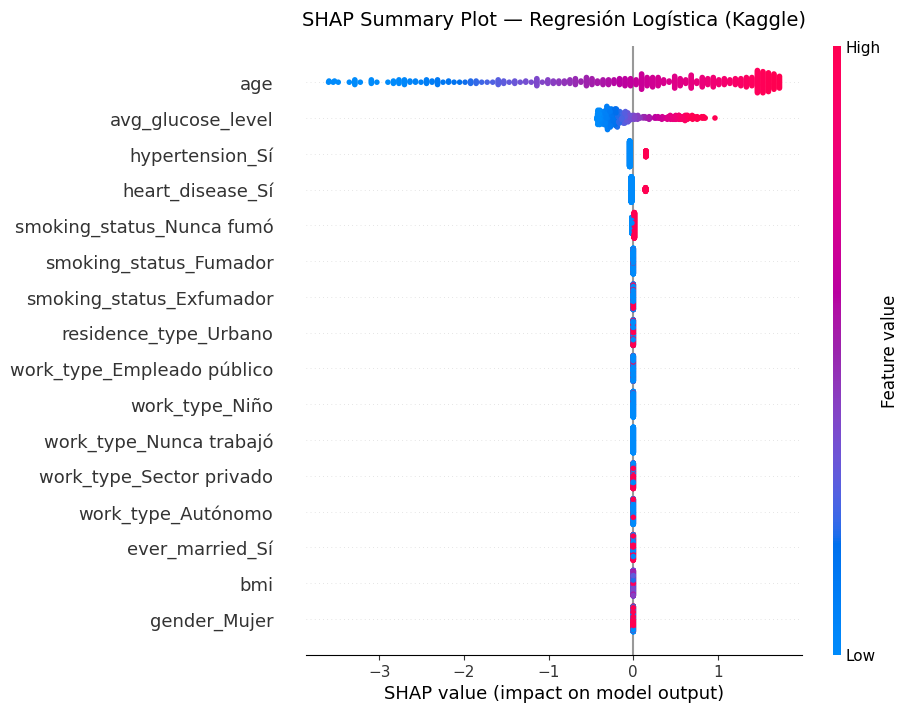

In [9]:
# Motor de explicaciones usando como referencia los datos del entrenamiento
explainer_lr   = shap.Explainer(best_lr_under2, x_train_UNDER)

#Extraemos los valores SHAP
shap_values_lr = explainer_lr(x_train_UNDER)
shap_matrix_lr = shap_values_lr.values

#Summary plot de SHAP para Regresión Logística
shap.plots.beeswarm(shap_values_lr, max_display=20, show=False)
plt.title("SHAP Summary Plot — Regresión Logística (Kaggle)", fontsize=14, pad=15)
plt.show()

# Calculamos el SHAP medio de cada variable del modelo
shap_importance_lr = importancia_shap(shap_matrix_lr, x_train_UNDER.columns)

##Redes neuronales

PermutationExplainer explainer: 399it [00:39,  8.39it/s]


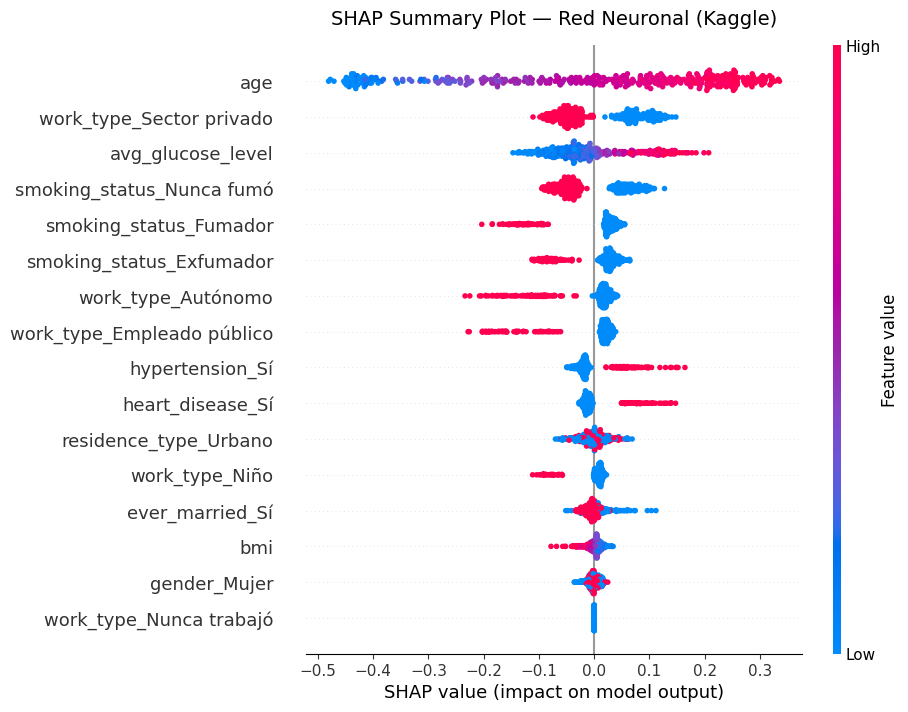

In [10]:
# Motor de explicaciones usando como referencia los datos del entrenamiento
explainer_nn   = shap.Explainer(modelo_final_nn_under, x_train_UNDER)

# Extraemos los valores de SHAP.
shap_values_nn = explainer_nn(x_train_UNDER)
shap_matrix_nn = np.squeeze(shap_values_nn.values)

#Summary plot
shap.plots.beeswarm(shap_values_nn, max_display=20, show=False)
plt.title("SHAP Summary Plot — Red Neuronal (Kaggle)", fontsize=14, pad=15)
plt.show()

# Calculamos el SHAP medio de cada variable del modelo
shap_importance_nn = importancia_shap(shap_matrix_nn, x_train_UNDER.columns)

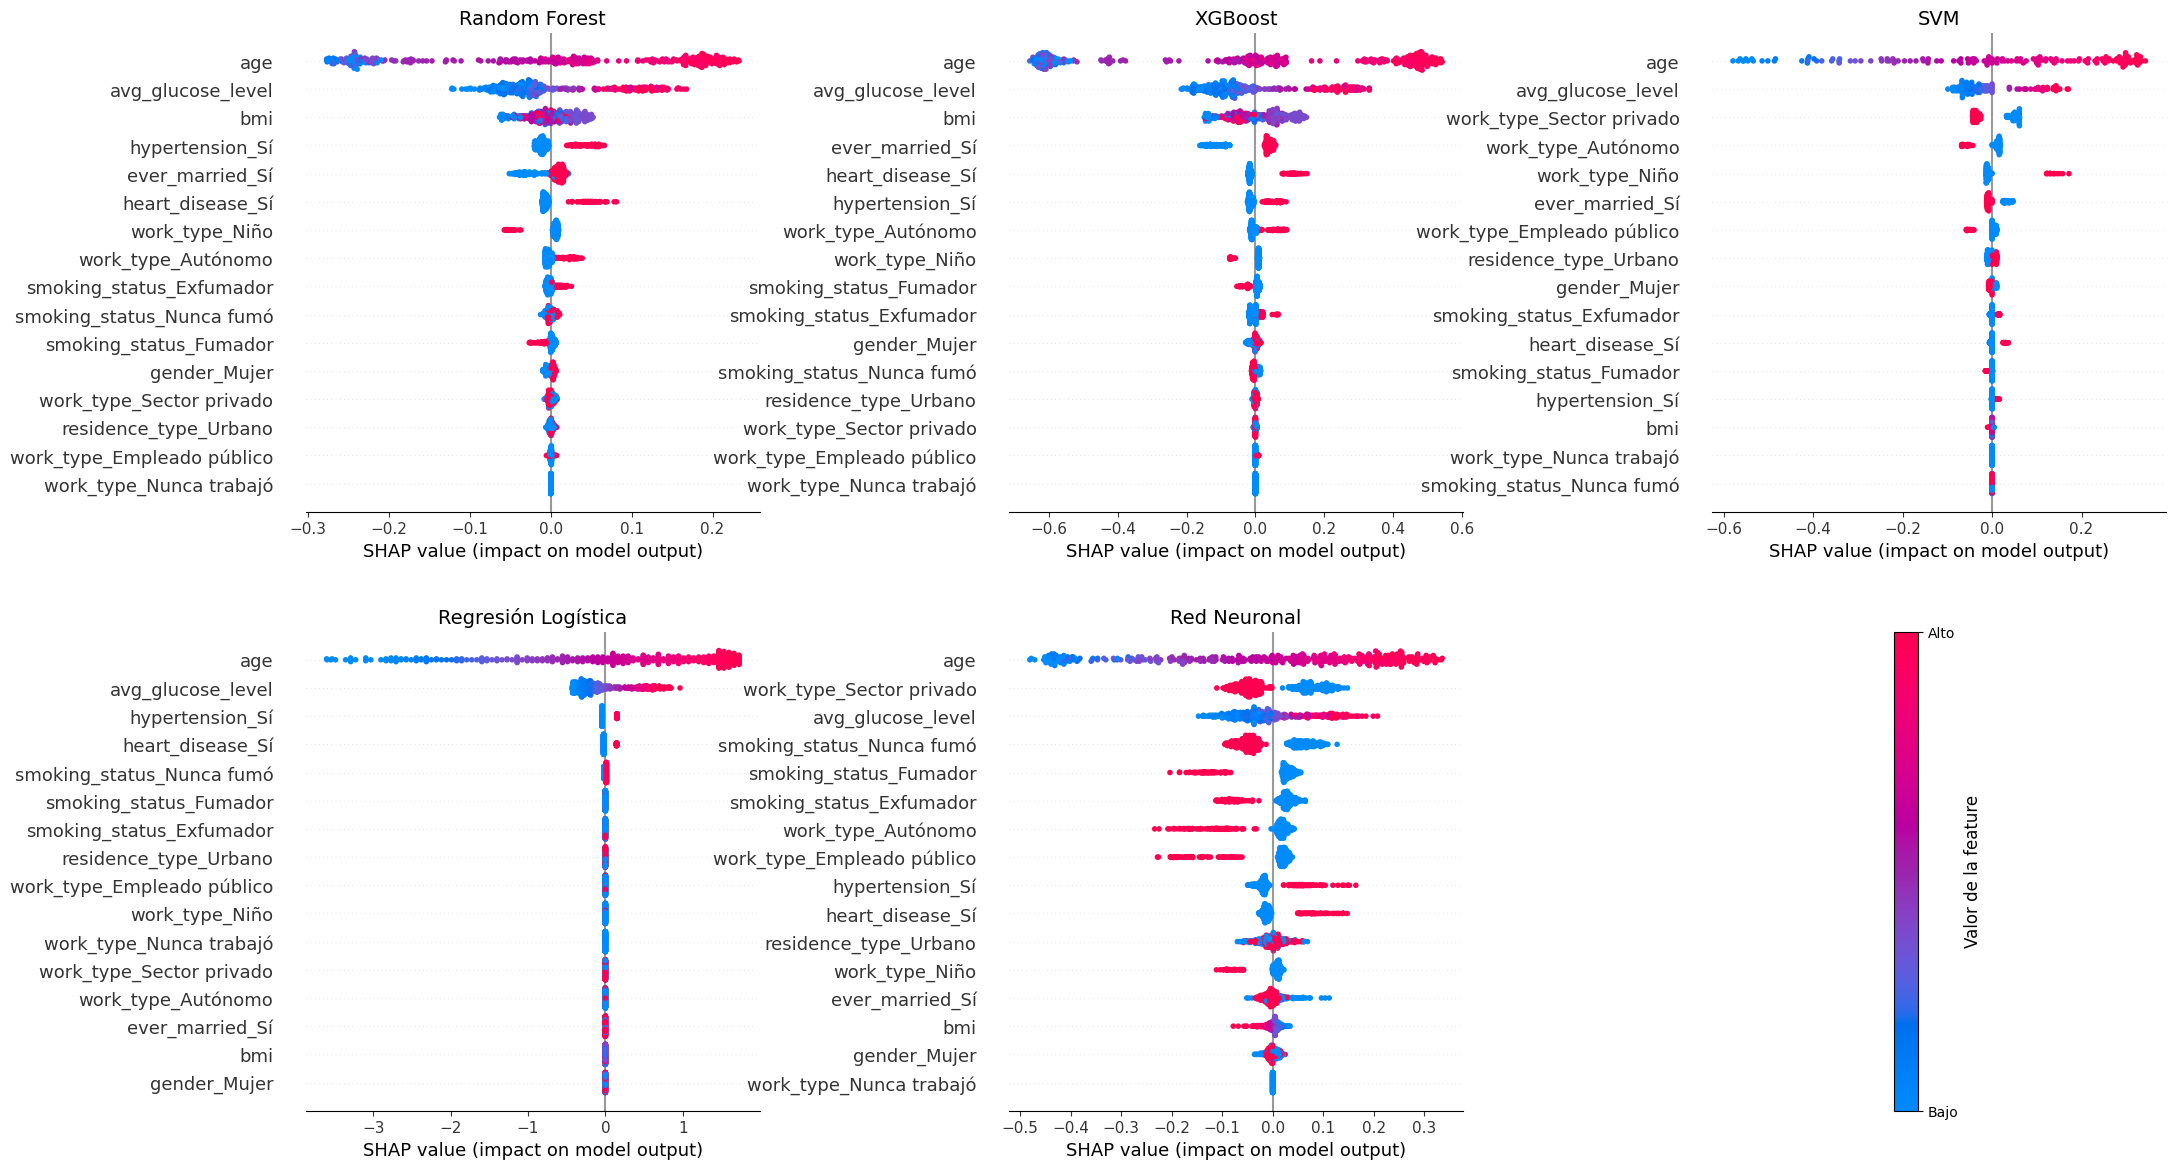

In [12]:
# Figura conjunta 2x3 con todos los beeswarm plots

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

# RANDOM FOREST
plt.sca(axes[0])
shap.plots.beeswarm(
    shap_values_rf[:, :, 1],
    max_display=20,
    show=False,
    plot_size=None,
    color_bar=False
)
axes[0].set_title("Random Forest", fontsize=14)

# XGBOOST
plt.sca(axes[1])
shap.plots.beeswarm(
    shap_values_xgb,
    max_display=20,
    show=False,
    plot_size=None,
    color_bar=False
)
axes[1].set_title("XGBoost", fontsize=14)

# SVM
plt.sca(axes[2])
shap.plots.beeswarm(
    shap_values_svm[:, :, 1],
    max_display=20,
    show=False,
    plot_size=None,
    color_bar=False
)
axes[2].set_title("SVM", fontsize=14)

# REGRESIÓN LOGÍSTICA
plt.sca(axes[3])
shap.plots.beeswarm(
    shap_values_lr,
    max_display=20,
    show=False,
    plot_size=None,
    color_bar=False
)
axes[3].set_title("Regresión Logística", fontsize=14)

# RED NEURONAL
plt.sca(axes[4])
shap.plots.beeswarm(
    shap_values_nn,
    max_display=20,
    show=False,
    plot_size=None,
    color_bar=False
)
axes[4].set_title("Red Neuronal", fontsize=14)

# Sexto panel: colorbar compartida en lugar de eje vacío
axes[5].axis("off")
sm = plt.cm.ScalarMappable(cmap=shap.plots.colors.red_blue)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[5], fraction=0.6, aspect=20)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["Bajo", "Alto"])
cbar.set_label("Valor de la feature", fontsize=12)

# Espaciado manual
fig.subplots_adjust(hspace=0.25, wspace=0.55)
plt.show()

Gráfico de barras para los valores medios de SHAP por variable en cada modelo

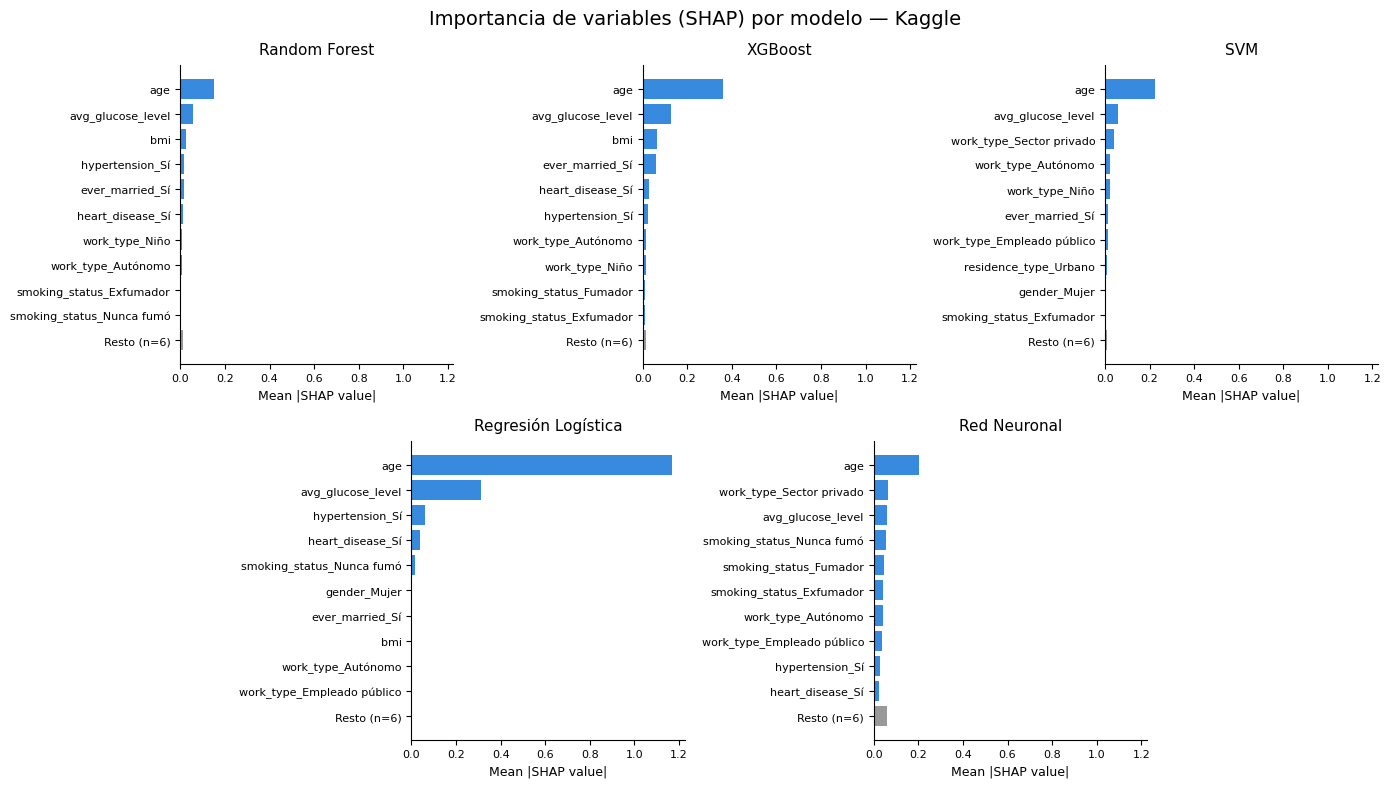

In [ ]:
# Parámetros
top_n = 10
modelos_shap = {
    "Random Forest":       shap_importance_rf,
    "XGBoost":             shap_importance_xgb,
    "SVM":                 shap_importance_svm,
    "Regresión Logística": shap_importance_lr,
    "Red Neuronal":        shap_importance_nn,
}

# Preparar datos: top_n + barra agregada "Otras"
def top_n_con_resto(tabla, top_n):
    df = tabla.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    top   = df.head(top_n).copy()
    resto = df.iloc[top_n:]
    if len(resto) > 0:
        fila_resto = pd.DataFrame({
            "feature":       [f"Resto (n={len(resto)})"],
            "mean_abs_shap": [resto["mean_abs_shap"].sum()],
        })
        return pd.concat([top, fila_resto], ignore_index=True)
    return top

modelos_prep = {n: top_n_con_resto(t, top_n) for n, t in modelos_shap.items()}

# Escala común
xmax_global = max(df["mean_abs_shap"].max() for df in modelos_prep.values())

# Figura
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 6, figure=fig)
axes = [
    fig.add_subplot(gs[0, 0:2]),
    fig.add_subplot(gs[0, 2:4]),
    fig.add_subplot(gs[0, 4:6]),
    fig.add_subplot(gs[1, 1:3]),
    fig.add_subplot(gs[1, 3:5]),
]

for ax, (nombre, df_plot) in zip(axes, modelos_prep.items()):
    # Azul para variables individuales, gris para la barra agregada
    colores = ["#378ADD"] * top_n + ["#999999"]
    ax.barh(df_plot["feature"], df_plot["mean_abs_shap"],
            color=colores[:len(df_plot)])
    ax.invert_yaxis()
    ax.set_title(nombre, pad=8, fontsize=11)
    ax.set_xlabel("Mean |SHAP value|", fontsize=9)
    ax.set_xlim(0, xmax_global * 1.05)
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=8)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)

fig.suptitle("Importancia de variables (SHAP) por modelo — Kaggle",
             fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

# XAIqi

Unimos el valor medio de SHAP de todas las variables de todos los modelos en una misma tabla

In [ ]:
# Añadimos modelo a cada tabla
rf = shap_importance_rf.copy()
rf["model"] = "rf" #Random Forest

xgb = shap_importance_xgb.copy()
xgb["model"] = "xgb" #XGboost

svm = shap_importance_svm.copy()
svm["model"] = "svm" #Supported Vector Machine

lr = shap_importance_lr.copy()
lr["model"] = "lr" #Regresión Logística

nn = shap_importance_nn.copy()
nn["model"] = "nn" #Red Neuronal

#Unimos todos los SHAP en un dataframe
all_shap = pd.concat([rf, xgb, svm, lr, nn])

Normalizamos los valores de SHAP dentro de cada modelo

In [ ]:
# Normalizamos los SHAP dentro de cada modelo
all_shap["shap_norm"] = all_shap.groupby("model")["mean_abs_shap"].transform(
    lambda x: x / x.sum()
)

# Pivotamos: una fila por feature, una columna por modelo
shap_wide = all_shap.pivot_table(
    index="feature",
    columns="model",
    values="shap_norm",
    fill_value=0
)

shap_wide

model,lr,nn,rf,svm,xgb
feature,,,,,
age,0.732607,0.305313,0.482827,0.525851,0.498048
avg_glucose_level,0.195990,0.091330,0.183265,0.142413,0.173076
bmi,0.000000,0.014805,0.075026,0.001389,0.088834
ever_married_Sí,0.000000,0.019708,0.046706,0.035839,0.080575
gender_Mujer,0.000000,0.011549,0.010219,0.014707,0.008624
heart_disease_Sí,0.023388,0.033814,0.039853,0.010139,0.038328
hypertension_Sí,0.039197,0.045082,0.057584,0.004442,0.030696
residence_type_Urbano,0.000000,0.024335,0.005291,0.020175,0.003773
smoking_status_Exfumador,0.000000,0.062234,0.013495,0.011090,0.013124


Media y desviación estándar de cada feature (de cada fila)

In [ ]:
# Media y desviación estándar por feature
mu = shap_wide.mean(axis=1)
sigma = shap_wide.std(axis=1)

Calculamos XAIqi para cada feature

In [ ]:
# Fórmula de XAIqi
xaiqi = mu * (1 - sigma)

# Lo aplicamos a cada feature
xaiqi_df = pd.DataFrame({
    "feature": xaiqi.index,
    "mu": mu.values,
    "sigma": sigma.values,
    "XAIqi": xaiqi.values
}).sort_values("XAIqi", ascending=False).reset_index(drop=True)

xaiqi_df

,feature,mu,sigma,XAIqi
0,age,0.508929,0.152133,0.431505
1,avg_glucose_level,0.157215,0.041814,0.150641
2,work_type_Sector privado,0.040878,0.051865,0.038758
3,ever_married_Sí,0.036566,0.030255,0.035459
4,hypertension_Sí,0.035400,0.019880,0.034696
5,bmi,0.036011,0.042596,0.034477
6,work_type_Autónomo,0.031186,0.024179,0.030432
7,heart_disease_Sí,0.029104,0.012401,0.028743
8,work_type_Niño,0.024114,0.018345,0.023671
9,smoking_status_Nunca fumó,0.022709,0.035108,0.021912


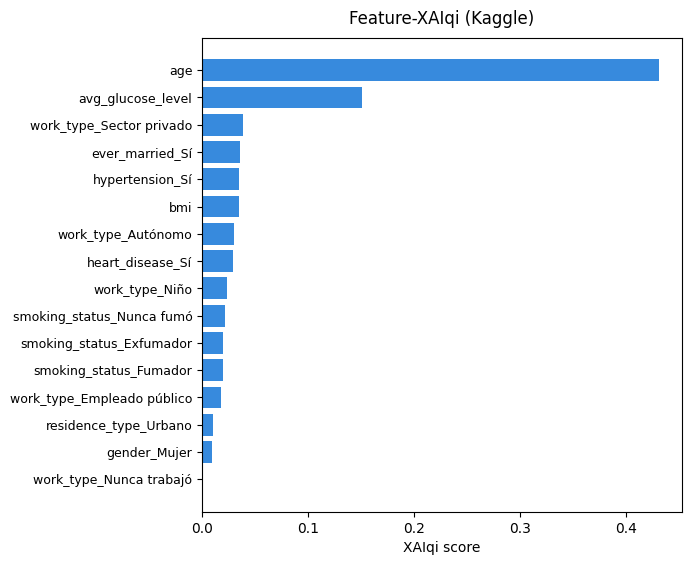

In [ ]:
top_n = 16
df_plot = xaiqi_df.head(top_n)

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(df_plot["feature"], df_plot["XAIqi"], color="#378ADD")

ax.set_xlabel("XAIqi score")
ax.set_title("Feature-XAIqi (Kaggle)", pad=10)

ax.invert_yaxis()
ax.tick_params(axis='y', labelsize=9)

plt.subplots_adjust(left=0.3, top=0.9)

plt.show()

# XAIci

In [ ]:
from scipy.stats import spearmanr

Alineamos las features de la matriz de XAI

In [ ]:
#Ponemos las features de ambos datasets en el mismo orden
pivot_sorted = shap_wide.loc[xaiqi_df["feature"]]

#Extraemos los valores numéricos de XAIqi
xaiqi_values = xaiqi_df["XAIqi"].values

Comparamos uno por uno el orden de las features de cada modelo según SHAP y el orden global de las features según XAIqi

In [ ]:
correlations = {} #Diccionario vacío para guardar los SHAP de cada modelo

#Bucle para recorrer todos los modelos
for model in shap_wide.columns:
    shap_values_model = pivot_sorted[model].values #Guardamos los SHAP values de cada modelo

    rho, _ = spearmanr(shap_values_model, xaiqi_values) #Comparamos el orden de las variables con XAIqi
    correlations[model] = rho #Guardamos el resultado de la correlación para cada modelo

Guardamos las correlaciones de cada modelo como dataframe

In [ ]:
corr_df = pd.DataFrame({
    "model": correlations.keys(),
    "spearman_corr": correlations.values()
}).sort_values(by="spearman_corr", ascending=False).reset_index(drop=True)

corr_df

,model,spearman_corr
0,rf,0.797059
1,xgb,0.741176
2,lr,0.557855
3,svm,0.550405
4,nn,0.529412


Calculamos el XAIci global como la media de las correlaciones de Spearman de cada modelo

In [ ]:
#Calculamos el valor de XAIci
XAIci_global = corr_df["spearman_corr"].mean()
print("XAIci global:", round(XAIci_global, 4))

XAIci global: 0.6352


In [ ]:
# Guardamos resultados XAI
xaiqi_df.to_csv(RUTA_BASE + "xaiqi_features.csv", index=False)
corr_df.to_csv(RUTA_BASE + "xaiqi_correlaciones.csv", index=False)

## Boostrap de incertidumbre para XAIci

In [ ]:
# =====================================================================
#  BOOTSTRAP DE INCERTIDUMBRE PARA XAIci
# ---------------------------------------------------------------------
# --- 1. Adaptador: matrices SHAP por instancia ya existentes en memoria ---
#     (deben estar calculadas: ejecutar esta celda DESPUES de la seccion
#      de SHAP, sin reiniciar el entorno)
shap_matrices = {
    "Random Forest":       shap_matrix_rf,
    "XGBoost":             shap_matrix_xgb,
    "SVM":                 shap_matrix_svm,
    "Regresión Logística": shap_matrix_lr,
    "Red Neuronal":        shap_matrix_nn,
}
feature_names = list(x_train_UNDER.columns)
P = len(feature_names)

# Coercion a 2D float (n_instancias x P) y |.| precomputado
ABS = {}
for name, M in shap_matrices.items():
    A = np.asarray(M, dtype=float)
    A = np.squeeze(A)
    if A.ndim == 3:                       # p.ej. (n, P, 1)
        A = A.reshape(A.shape[0], -1)
    assert A.shape[1] == P, f"{name}: {A.shape[1]} columnas != {P} features"
    ABS[name] = np.abs(A)                 # (n_m, P)

MODELS = list(ABS.keys())

# --- 2. Funcion XAIci que replica el pipeline exacto ---------------------
def xaici_from_importances(imp_by_model):
    """imp_by_model: dict modelo -> vector de importancia (sin normalizar), long P."""
    cols = []
    for m in MODELS:
        v = imp_by_model[m]
        s = v.sum()
        cols.append(v / s if s > 0 else np.zeros_like(v))
    wide = np.column_stack(cols)                 # (P, M), columnas = modelos
    mu    = wide.mean(axis=1)
    sigma = wide.std(axis=1, ddof=1)             # pandas .std usa ddof=1
    xaiqi = mu * (1.0 - sigma)
    rhos = {}
    for j, m in enumerate(MODELS):
        rho, _ = spearmanr(wide[:, j], xaiqi)
        rhos[m] = rho
    vals = np.array([rhos[m] for m in MODELS], dtype=float)
    return np.nanmean(vals), rhos

def importances_resampled(rng=None):
    """Importancia media de |SHAP| por modelo; rng=None -> muestra original."""
    out = {}
    for m in MODELS:
        Am = ABS[m]
        if rng is None:
            out[m] = Am.mean(axis=0)
        else:
            idx = rng.integers(0, Am.shape[0], Am.shape[0])  # bootstrap propio
            out[m] = Am[idx].mean(axis=0)
    return out

# --- 3. Bootstrap --------------------------------------------------------
B    = 2000
SEED = 42
rng  = np.random.default_rng(SEED)

boot_xaici = np.empty(B)
boot_rhos  = {m: np.empty(B) for m in MODELS}
for b in range(B):
    xb, rb = xaici_from_importances(importances_resampled(rng))
    boot_xaici[b] = xb
    for m in MODELS:
        boot_rhos[m][b] = rb[m]

def resumen(arr, etiqueta):
    arr = arr[~np.isnan(arr)]
    media = arr.mean(); se = arr.std(ddof=1)
    lo, hi = np.percentile(arr, [2.5, 97.5])
    return {"magnitud": etiqueta, "estimacion": None, "media_boot": media,
            "EE": se, "IC95_inf": lo, "IC95_sup": hi}

# Estimación puntual sobre la muestra original (sin remuestreo)
xaici_point, rhos_point = xaici_from_importances(importances_resampled(rng=None))

filas = []
r = resumen(boot_xaici, "XAIci global"); r["estimacion"] = xaici_point
filas.append(r)
for m in MODELS:
    r = resumen(boot_rhos[m], f"rho {m}"); r["estimacion"] = rhos_point[m]
    filas.append(r)

resumen_df = pd.DataFrame(filas)[
    ["magnitud", "estimacion", "media_boot", "EE", "IC95_inf", "IC95_sup"]
].round(4)
print("\n=== Bootstrap de XAIci (B={}, semilla={}) ===".format(B, SEED))
print(resumen_df.to_string(index=False))

# Guardado coherente con el resto del notebook
resumen_df.to_csv(RUTA_BASE + "xaici_bootstrap_resumen.csv", index=False)
pd.DataFrame({"xaici_boot": boot_xaici}).to_csv(
    RUTA_BASE + "xaici_bootstrap_draws.csv", index=False)


=== Bootstrap de XAIci (B=2000, semilla=42) ===
               magnitud  estimacion  media_boot     EE  IC95_inf  IC95_sup
           XAIci global      0.6352      0.6326 0.0064    0.6200    0.6438
      rho Random Forest      0.7971      0.7928 0.0090    0.7706    0.8059
            rho XGBoost      0.7412      0.7430 0.0120    0.7118    0.7647
                rho SVM      0.5504      0.5435 0.0214    0.4945    0.5798
rho Regresión Logística      0.5579      0.5575 0.0233    0.5292    0.6079
       rho Red Neuronal      0.5294      0.5264 0.0194    0.4912    0.5676


# Variación de features y modelos

Código común para reentrenamiento por eliminación de ruido y por ablación de features dominantes

In [ ]:
# ── Parámetros generales ──────────────────────────────────────
N_ITER = 30
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=24)

# ── Métricas para RandomizedSearchCV ──────────────────────────
scoring_str = {
    "Recall":   make_scorer(recall_score, pos_label="Sí"),
    "F1":       make_scorer(f1_score,     pos_label="Sí"),
    "AUROC":    "roc_auc",
    "Accuracy": "accuracy",
    "BalAcc":   "balanced_accuracy",
}
scoring_bin = {
    "Recall":   make_scorer(recall_score, pos_label=1),
    "F1":       make_scorer(f1_score,     pos_label=1),
    "AUROC":    "roc_auc",
    "Accuracy": "accuracy",
    "BalAcc":   "balanced_accuracy",
}

# ── Rejillas de hiperparámetros ───────────────────────────────
GRID_RF = {
    "n_estimators":      [100, 200, 300, 400],
    "max_depth":         [5, 10, 15, 20],
    "min_samples_split": [5, 10, 15],
    "min_samples_leaf":  [2, 4, 6],
    "max_features":      ["log2", "sqrt"],
}
GRID_XGB = {
    "n_estimators":     [50, 100, 150, 200],
    "max_depth":        [2, 3, 4, 5],
    "learning_rate":    [0.005, 0.01, 0.02, 0.05],
    "subsample":        [0.5, 0.6, 0.7, 0.8],
    "colsample_bytree": [0.5, 0.6, 0.7, 0.8],
}
GRID_SVM = {
    "C":      [0.01, 0.1, 1, 5, 10, 25, 50, 100, 200, 500],
    "kernel": ["linear", "rbf", "poly"],
    "gamma":  ["scale", "auto"],
}
GRID_LR = {
    "C":       [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10],
    "penalty": ["l1", "l2"],
    "solver":  ["liblinear", "saga"],
}
GRID_NN = {
    "model__optimizer_name": ["adam"],
    "model__learning_rate":  [0.005, 0.01, 0.015, 0.02],
    "model__hidden_layer_1": [16, 32, 48, 64],
    "model__dropout_1":      [0.4, 0.5, 0.55, 0.6],
}

# ── Arquitectura de la red neuronal ──────────────────────────
def build_model(hidden_layer_1=64, dropout_1=0.2,
                optimizer_name="adam", learning_rate=0.01, meta=None):
    n_feat = meta["n_features_in_"]
    model = Sequential([
        Input(shape=(n_feat,)),
        Dense(hidden_layer_1, activation="relu"),
        Dropout(dropout_1),
        Dense(1, activation="sigmoid"),
    ])
    opt = Adam(learning_rate=learning_rate) if optimizer_name == "adam" \
          else SGD(learning_rate=learning_rate)
    model.compile(optimizer=opt, loss="binary_crossentropy", metrics=["AUC"])
    return model

# ── Evaluación en test (autodetecta tipo de etiqueta) ─────────
def evaluar_modelo_test(modelo, X_test, y_test_str, y_test_bin, label_type=None):
    """
    Devuelve Recall, F1, AUROC, Precision, Accuracy, BalAcc sobre el test set.
    Si label_type=None, se detecta inspeccionando modelo.classes_.
    """
    if label_type is None:
        if hasattr(modelo, "classes_"):
            label_type = "str" if "Sí" in list(modelo.classes_) else "bin"
        else:
            label_type = "bin"   # Keras puro no tiene classes_

    if label_type == "str":
        y_true  = y_test_str
        y_pred  = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, list(modelo.classes_).index("Sí")]
        pos     = "Sí"
        y_true_bin_auroc = (y_true == pos).astype(int)
    else:
        y_true = y_test_bin
        if hasattr(modelo, "predict_proba"):
            y_pred  = modelo.predict(X_test)
            y_proba = modelo.predict_proba(X_test)[:, 1]
        else:
            y_proba = modelo.predict(X_test).ravel()
            y_pred  = (y_proba >= 0.5).astype(int)
        pos = 1
        y_true_bin_auroc = y_true

    return {
        "Recall":    recall_score(y_true, y_pred, pos_label=pos),
        "F1":        f1_score(y_true, y_pred, pos_label=pos),
        "AUROC":     roc_auc_score(y_true_bin_auroc, y_proba),
        "Precision": precision_score(y_true, y_pred, pos_label=pos),
        "Accuracy":  accuracy_score(y_true, y_pred),
        "BalAcc":    balanced_accuracy_score(y_true, y_pred),
    }

# ── Helper: entrenar los 5 modelos, calcular SHAP y métricas ──
def entrenar_y_evaluar_5_modelos(X_tr, X_te, y_str, y_bin,
                                  y_test_str, y_test_bin):
    """
    Reentrena RF, XGB, SVM, LR y NN con RandomizedSearchCV sobre (X_tr, y_*),
    calcula mean|SHAP| sobre X_tr y evalúa cada modelo en (X_te, y_test_*).
    Devuelve (shap_mean, metricas_test).
    """
    shap_mean, metricas_test = {}, {}

    # ---------- Random Forest -----------
    print("  [1/5] Random Forest…")
    rs = RandomizedSearchCV(
        RandomForestClassifier(random_state=24),
        GRID_RF, n_iter=N_ITER, cv=cv,
        scoring=scoring_str, refit="AUROC",
        n_jobs=-1, verbose=0, random_state=24,
    ).fit(X_tr, y_str)
    best_rf = rs.best_estimator_
    metricas_test["rf"] = evaluar_modelo_test(
        best_rf, X_te, y_test_str, y_test_bin, label_type="str")
    sv = shap.Explainer(best_rf, X_tr)(X_tr)
    shap_mean["rf"] = np.abs(sv[:, :, 1].values).mean(axis=0)

    # ---------- XGBoost -----------------
    print("  [2/5] XGBoost…")
    rs = RandomizedSearchCV(
        XGBClassifier(random_state=24, eval_metric="auc"),
        GRID_XGB, n_iter=N_ITER, cv=cv,
        scoring=scoring_bin, refit="AUROC",
        n_jobs=-1, verbose=0, random_state=24,
    ).fit(X_tr, y_bin)
    best_xgb = rs.best_estimator_
    metricas_test["xgb"] = evaluar_modelo_test(
        best_xgb, X_te, y_test_str, y_test_bin, label_type="bin")
    sv = shap.Explainer(best_xgb, X_tr)(X_tr)
    shap_mean["xgb"] = np.abs(sv.values).mean(axis=0)

    # ---------- SVM ---------------------
    print("  [3/5] SVM (lento)…")
    rs = RandomizedSearchCV(
        SVC(random_state=24, probability=True),
        GRID_SVM, n_iter=N_ITER, cv=cv,
        scoring=scoring_str, refit="AUROC",
        n_jobs=-1, verbose=0, random_state=24,
    ).fit(X_tr, y_str)
    best_svm = rs.best_estimator_
    metricas_test["svm"] = evaluar_modelo_test(
        best_svm, X_te, y_test_str, y_test_bin, label_type="str")
    background = shap.kmeans(X_tr, 100)
    expl_svm   = shap.KernelExplainer(best_svm.predict_proba, background)
    X_small    = X_tr.sample(min(150, len(X_tr)), random_state=42)
    sv         = expl_svm(X_small)
    shap_mean["svm"] = np.abs(sv.values[:, :, 1]).mean(axis=0)

    # ---------- Logistic Regression -----
    print("  [4/5] Logistic Regression…")
    rs = RandomizedSearchCV(
        LogisticRegression(random_state=24, max_iter=1000),
        GRID_LR, n_iter=N_ITER, cv=cv,
        scoring=scoring_str, refit="AUROC",
        n_jobs=-1, verbose=0, random_state=24,
    ).fit(X_tr, y_str)
    best_lr = rs.best_estimator_
    metricas_test["lr"] = evaluar_modelo_test(
        best_lr, X_te, y_test_str, y_test_bin, label_type="str")
    sv = shap.Explainer(best_lr, X_tr)(X_tr)
    shap_mean["lr"] = np.abs(sv.values).mean(axis=0)

    # ---------- Red neuronal ------------
    print("  [5/5] Red Neuronal…")
    mlp = KerasClassifier(
        model=build_model,
        epochs=30, batch_size=32, verbose=0, random_state=24,
    )
    rs = RandomizedSearchCV(
        mlp, GRID_NN, n_iter=N_ITER, cv=cv,
        scoring=scoring_bin, refit="AUROC",
        n_jobs=1, verbose=0, random_state=24,
    ).fit(X_tr.values, y_bin.values)
    best_nn = rs.best_estimator_
    keras_m = best_nn.model_
    metricas_test["nn"] = evaluar_modelo_test(
        best_nn, X_te.values, y_test_str, y_test_bin, label_type="bin")
    bg_nn = X_tr.sample(min(200, len(X_tr)), random_state=42).values
    sv    = shap.Explainer(keras_m, bg_nn)(X_tr.values)
    shap_mean["nn"] = np.abs(sv.values).mean(axis=0).ravel()

    return shap_mean, metricas_test

# ── Helper: construir shap_wide, XAIqi y XAIci a partir de shap_mean ──
def construir_xai_local(shap_mean, feats):
    """
    A partir de shap_mean (dict modelo -> vector |SHAP| medio) y feats,
    construye shap_wide normalizada, xaiqi_local_df, corr_local_df y XAIci.
    """
    frames = [pd.DataFrame({"feature": feats, "mean_abs_shap": arr, "model": m})
              for m, arr in shap_mean.items()]
    all_shap = pd.concat(frames, ignore_index=True)
    all_shap["shap_norm"] = all_shap.groupby("model")["mean_abs_shap"] \
        .transform(lambda x: x / x.sum() if x.sum() > 0 else x)
    shap_wide = all_shap.pivot_table(
        index="feature", columns="model", values="shap_norm", fill_value=0)

    mu, sigma = shap_wide.mean(axis=1), shap_wide.std(axis=1)
    xaiqi_local = (mu * (1 - sigma)).sort_values(ascending=False)
    xaiqi_local_df = pd.DataFrame({
        "feature": xaiqi_local.index,
        "mu":      mu.loc[xaiqi_local.index].values,
        "sigma":   sigma.loc[xaiqi_local.index].values,
        "XAIqi":   xaiqi_local.values,
    }).reset_index(drop=True)

    shap_wide_sorted = shap_wide.loc[xaiqi_local_df["feature"]]
    xaiqi_vals = xaiqi_local_df["XAIqi"].values
    corrs = {m: spearmanr(shap_wide_sorted[m].values, xaiqi_vals)[0]
             for m in shap_wide.columns}
    xaici = float(np.nanmean(list(corrs.values())))
    corr_local_df = pd.DataFrame({
        "model": list(corrs), "spearman_corr": list(corrs.values())})

    return shap_wide, xaiqi_local_df, corr_local_df, xaici

# ── Constantes y helper de resumen de métricas ────────────────
METRICAS_NOMBRES = ["AUROC", "F1", "Recall", "Precision", "Accuracy", "BalAcc"]

def resumir_metricas(metricas_por_modelo):
    """metricas_por_modelo: dict modelo -> dict métrica -> valor."""
    df = pd.DataFrame(metricas_por_modelo).T   # filas = modelos, cols = métricas
    summary = pd.DataFrame({
        "mean": df.mean(axis=0),
        "std":  df.std(axis=0),
    })
    return df, summary

def _log_xaici_metricas(xaici, metricas_summary):
    print(f"   →  XAIci = {xaici:.4f}")
    print("   Métricas en test (media ± std entre 5 modelos):")
    for metric, row in metricas_summary.iterrows():
        print(f"     {metric:<10} {row['mean']:.3f} ± {row['std']:.3f}")

def _evaluar_modelos_preentrenados(modelos, X_te, y_test_str, y_test_bin):
    """Aplica evaluar_modelo_test a un dict de modelos ya entrenados."""
    out = {n: evaluar_modelo_test(modelos[n], X_te, y_test_str, y_test_bin)
           for n in ["rf", "xgb", "svm", "lr"]}
    out["nn"] = evaluar_modelo_test(
        modelos["nn"], X_te.values, y_test_str, y_test_bin, "bin")
    return out



 # ── Función: poda por umbral de XAIqi ─────────────────────────
def evaluar_umbral(tau, xaiqi_df, X_full, y_str, y_bin,
                   X_test, y_test_str, y_test_bin,
                   modelos_preentrenados=None,
                   xaiqi_original=None,
                   corr_original=None):
    feats = xaiqi_df.loc[xaiqi_df["XAIqi"] >= tau, "feature"].tolist()
    n_feats = len(feats)
    print(f"\n{'='*64}\nUMBRAL XAIqi ≥ {tau:.3f}   ·   #features = {n_feats}\n{'='*64}")
    if n_feats < 2:
        print("  Features insuficientes, se omite.")
        return None

    # ── Atajo: si no se elimina ninguna feature, reutilizar modelos y XAIci ──
    set_completo = set(feats) == set(X_full.columns)
    if (set_completo
            and modelos_preentrenados is not None
            and xaiqi_original is not None
            and corr_original is not None):
        print("  (reutilizando modelos y XAIci originales — sin reentrenar)")
        metricas_test = _evaluar_modelos_preentrenados(
            modelos_preentrenados, X_test.copy(), y_test_str, y_test_bin)
        xaiqi_local_df = xaiqi_original.copy().reset_index(drop=True)
        corr_local_df  = corr_original.copy().reset_index(drop=True)
        xaici = float(corr_local_df["spearman_corr"].mean())
    else:
        # ── Reentrenamiento completo ──
        X_tr = X_full[feats].copy()
        X_te = X_test[feats].copy()
        shap_mean, metricas_test = entrenar_y_evaluar_5_modelos(
            X_tr, X_te, y_str, y_bin, y_test_str, y_test_bin)
        _, xaiqi_local_df, corr_local_df, xaici = construir_xai_local(
            shap_mean, feats)

    metricas_df, metricas_summary = resumir_metricas(metricas_test)
    _log_xaici_metricas(xaici, metricas_summary)

    return {
        "umbral":              tau,
        "n_features":          n_feats,
        "xaiqi_df":            xaiqi_local_df,
        "corr_df":             corr_local_df,
        "XAIci":               xaici,
        "metricas_por_modelo": metricas_df,
        "metricas_summary":    metricas_summary,
    }


# ── Función: ablación de las top-k features de XAIqi ──────────
def evaluar_ablation(k, xaiqi_df, X_full, X_test, y_str, y_bin,
                     y_test_str, y_test_bin,
                     modelos_preentrenados=None,
                     xaiqi_original=None,
                     corr_original=None):
    feats_drop = xaiqi_df["feature"].head(k).tolist()
    feats      = [f for f in xaiqi_df["feature"] if f not in feats_drop]
    n_feats    = len(feats)

    print(f"\n{'='*64}")
    if k == 0:
        print(f"BASELINE (sin eliminar features)\n#features = {n_feats}")
    else:
        print(f"ELIMINADAS TOP-{k}: {feats_drop}\n#features restantes = {n_feats}")
    print(f"{'='*64}")

    if n_feats < 2:
        print("  Features insuficientes, se omite.")
        return None

    # ── Atajo: si k=0, reutilizar modelos y XAIci originales ──
    if (k == 0
            and modelos_preentrenados is not None
            and xaiqi_original is not None
            and corr_original is not None):
        print("  (reutilizando modelos y XAIci originales — sin reentrenar)")
        metricas_test = _evaluar_modelos_preentrenados(
            modelos_preentrenados, X_test.copy(), y_test_str, y_test_bin)
        xaiqi_local_df = xaiqi_original.copy().reset_index(drop=True)
        corr_local_df  = corr_original.copy().reset_index(drop=True)
        xaici = float(corr_local_df["spearman_corr"].mean())
    else:
        # ── Reentrenamiento completo ──
        X_tr = X_full[feats].copy()
        X_te = X_test[feats].copy()
        shap_mean, metricas_test = entrenar_y_evaluar_5_modelos(
            X_tr, X_te, y_str, y_bin, y_test_str, y_test_bin)
        _, xaiqi_local_df, corr_local_df, xaici = construir_xai_local(
            shap_mean, feats)

    metricas_df, metricas_summary = resumir_metricas(metricas_test)
    _log_xaici_metricas(xaici, metricas_summary)

    # Llaves planas (AUROC_mean, etc.) para compatibilidad con resumen_abl
    metricas_resumen = {}
    for met in METRICAS_NOMBRES:
        metricas_resumen[f"{met}_mean"] = float(metricas_summary.loc[met, "mean"])
        metricas_resumen[f"{met}_std"]  = float(metricas_summary.loc[met, "std"])

    return {
        "k_drop":              k,
        "dropped":             feats_drop,
        "n_features":          n_feats,
        "xaiqi_df":            xaiqi_local_df,
        "corr_df":             corr_local_df,
        "XAIci":               xaici,
        "metricas_por_modelo": metricas_df,
        "metricas_summary":    metricas_summary,
        "metricas_m":          metricas_test,
        **metricas_resumen,
    }

## Eliminación de ruido

Reentrenamiento bajo distintos umbrales de XAIqi


UMBRAL XAIqi ≥ 0.000   ·   #features = 16
  (reutilizando modelos y XAIci originales — sin reentrenar)
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
   →  XAIci = 0.6352
   Métricas en test (media ± std entre 5 modelos):
     Recall     0.692 ± 0.033
     F1         0.198 ± 0.010
     AUROC      0.802 ± 0.006
     Precision  0.116 ± 0.006
     Accuracy   0.726 ± 0.005
     BalAcc     0.710 ± 0.018

UMBRAL XAIqi ≥ 0.010   ·   #features = 14
  [1/5] Random Forest…


 95%|=================== | 758/796 [00:17<00:00]       

  [2/5] XGBoost…
  [3/5] SVM (lento)…


  0%|          | 0/150 [00:00<?, ?it/s]

  [4/5] Logistic Regression…
  [5/5] Red Neuronal…


...

  [4/5] Logistic Regression…
  [5/5] Red Neuronal…
   →  XAIci = 0.7561
   Métricas en test (media ± std entre 5 modelos):
     Recall     0.724 ± 0.009
     F1         0.204 ± 0.006
     AUROC      0.797 ± 0.006
     Precision  0.119 ± 0.004
     Accuracy   0.724 ± 0.010
     BalAcc     0.724 ± 0.006

UMBRAL XAIqi ≥ 0.035   ·   #features = 4
  [1/5] Random Forest…


100%|===================| 794/796 [00:12<00:00]       

  [2/5] XGBoost…
  [3/5] SVM (lento)…


  0%|          | 0/150 [00:00<?, ?it/s]

  [4/5] Logistic Regression…
  [5/5] Red Neuronal…
   →  XAIci = 0.9600
   Métricas en test (media ± std entre 5 modelos):
     Recall     0.728 ± 0.018
     F1         0.206 ± 0.005
     AUROC      0.792 ± 0.007
     Precision  0.120 ± 0.003
     Accuracy   0.726 ± 0.009
     BalAcc     0.727 ± 0.008

=== RESUMEN ===
 umbral  n_features    XAIci  AUROC_mean  AUROC_std  F1_mean   F1_std  Recall_mean  Recall_std  Precision_mean  Precision_std  Accuracy_mean  Accuracy_std  BalAcc_mean  BalAcc_std
  0.000          16 0.635181    0.801751   0.006220 0.198187 0.009853        0.692    0.033466        0.115657       0.005808       0.726027      0.005037     0.709889    0.017681
  0.010          14 0.584250    0.802111   0.004568 0.200053 0.008193        0.708    0.026833        0.116491       0.004948       0.722896      0.007303     0.715831    0.014129
  0.020          10 0.673625    0.793679   0.011118 0.207319 0.007435        0.712    0.036332        0.121344       0.004314       0.733659

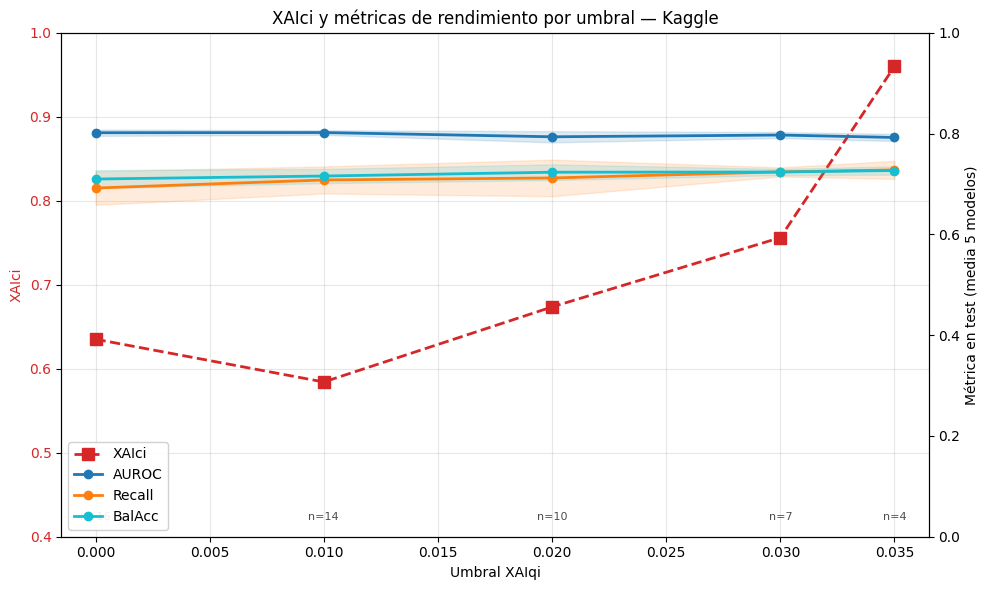

In [ ]:
# ════════════════════════════════════════════════════════════════
#  PODA POR UMBRAL DE XAIqi
# ════════════════════════════════════════════════════════════════

UMBRALES = [0.00, 0.01, 0.02, 0.03, 0.035]

# Modelos originales (para el atajo cuando tau=0)
modelos_originales = {
    "rf":  best_rf_under2,
    "xgb": best_xgb_under2,
    "svm": best_svm_under2,
    "lr":  best_lr_under2,
    "nn":  modelo_final_nn_under,
}

# ── Bucle sobre los umbrales ──────────────────────────────────
resultados = []
for tau in UMBRALES:
    r = evaluar_umbral(tau, xaiqi_df, x_train_UNDER,
                       y_train_UNDER, y_train_under_xgb,
                       x_test_final, y_test_final, y_test_bin,
                       modelos_preentrenados=modelos_originales,
                       xaiqi_original=xaiqi_df,
                       corr_original=corr_df)
    if r is not None:
        resultados.append(r)

# ── Tabla resumen ─────────────────────────────────────────────
resumen_rows = []
for r in resultados:
    row = {
        "umbral":     r["umbral"],
        "n_features": r["n_features"],
        "XAIci":      r["XAIci"],
    }
    for metric in METRICAS_NOMBRES:   # AUROC, F1, Recall, Precision, Accuracy, BalAcc
        row[f"{metric}_mean"] = r["metricas_summary"].loc[metric, "mean"]
        row[f"{metric}_std"]  = r["metricas_summary"].loc[metric, "std"]
    resumen_rows.append(row)

resumen = pd.DataFrame(resumen_rows)
print("\n=== RESUMEN ===")
print(resumen.to_string(index=False))

# ── Guardado ──────────────────────────────────────────────────
resumen.to_csv(RUTA_BASE + "xaici_por_umbral.csv", index=False)
for r in resultados:
    tag = f"{r['umbral']:.3f}".replace(".", "")
    r["xaiqi_df"].to_csv(RUTA_BASE + f"xaiqi_tau{tag}.csv", index=False)
    r["corr_df"].to_csv(RUTA_BASE + f"corr_tau{tag}.csv",  index=False)
    r["metricas_por_modelo"].to_csv(RUTA_BASE + f"metricas_tau{tag}.csv")

# ── Gráfico: XAIci + métricas por umbral ──────────────────────
resumen = resumen.sort_values("umbral").reset_index(drop=True)

umbrales_plot = resumen["umbral"].values
n_feats_plot  = resumen["n_features"].values
xaici_plot    = resumen["XAIci"].values

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(umbrales_plot, xaici_plot, "--s", color="tab:red",
        label="XAIci", linewidth=2, markersize=8)
ax.set_ylabel("XAIci", color="tab:red")
ax.tick_params(axis="y", labelcolor="tab:red")
ax.set_ylim(0.4, 1.0)

ax2 = ax.twinx()
colores = {
    "AUROC":  "tab:blue",
    "Recall": "tab:orange",
    "BalAcc": "tab:cyan",
}
for metric, color in colores.items():
    means = resumen[f"{metric}_mean"].values
    stds  = resumen[f"{metric}_std"].values
    ax2.plot(umbrales_plot, means, "-o", color=color, label=metric, linewidth=2)
    ax2.fill_between(umbrales_plot, means - stds, means + stds,
                     color=color, alpha=0.15)

ax.set_xlabel("Umbral XAIqi")
ax2.set_ylabel("Métrica en test (media 5 modelos)")
ax2.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

for x, n in zip(umbrales_plot, n_feats_plot):
    ax.annotate(f"n={int(n)}", xy=(x, 0.42), ha="center", fontsize=8, alpha=0.7)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="lower left", framealpha=0.9)

ax.set_title("XAIci y métricas de rendimiento por umbral — Kaggle")
ax.set_xlim(-0.0015, max(umbrales_plot) + 0.0015)
plt.tight_layout()
plt.savefig(RUTA_BASE + "panel_umbral_metricas.png", dpi=150, bbox_inches="tight")
plt.show()

## Eliminación de K-top features


BASELINE (sin eliminar features)
#features = 16
  (reutilizando modelos y XAIci originales — sin reentrenar)
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
   →  XAIci = 0.6352
   Métricas en test (media ± std entre 5 modelos):
     Recall     0.692 ± 0.033
     F1         0.198 ± 0.010
     AUROC      0.802 ± 0.006
     Precision  0.116 ± 0.006
     Accuracy   0.726 ± 0.005
     BalAcc     0.710 ± 0.018

ELIMINADAS TOP-1: ['age']
#features restantes = 15
  [1/5] Random Forest…


 98%|===================| 779/796 [00:16<00:00]       

  [2/5] XGBoost…
  [3/5] SVM (lento)…


  0%|          | 0/150 [00:00<?, ?it/s]

  [4/5] Logistic Regression…
  [5/5] Red Neuronal…


...

   →  XAIci = 0.7930
   Métricas en test (media ± std entre 5 modelos):
     Recall     0.568 ± 0.122
     F1         0.153 ± 0.024
     AUROC      0.705 ± 0.015
     Precision  0.090 ± 0.019
     Accuracy   0.680 ± 0.106
     BalAcc     0.627 ± 0.032

ELIMINADAS TOP-3: ['age', 'avg_glucose_level', 'work_type_Sector privado']
#features restantes = 13
  [1/5] Random Forest…
  [2/5] XGBoost…
  [3/5] SVM (lento)…


  0%|          | 0/150 [00:00<?, ?it/s]

  [4/5] Logistic Regression…
  [5/5] Red Neuronal…


PermutationExplainer explainer: 399it [00:46,  6.74it/s]                         


   →  XAIci = 0.8664
   Métricas en test (media ± std entre 5 modelos):
     Recall     0.608 ± 0.083
     F1         0.154 ± 0.013
     AUROC      0.711 ± 0.015
     Precision  0.088 ± 0.008
     Accuracy   0.674 ± 0.041
     BalAcc     0.642 ± 0.027

=== RESUMEN ABLATION (XAIci + métricas en test) ===
 k_eliminadas  n_restantes  XAIci  AUROC_mean  F1_mean  Recall_mean  Precision_mean  Accuracy_mean  BalAcc_mean
            0           16  0.635       0.802    0.198        0.692           0.116          0.726        0.710
            1           15  0.873       0.737    0.167        0.620           0.097          0.698        0.661
            2           14  0.793       0.705    0.153        0.568           0.090          0.680        0.627
            3           13  0.866       0.711    0.154        0.608           0.088          0.674        0.642


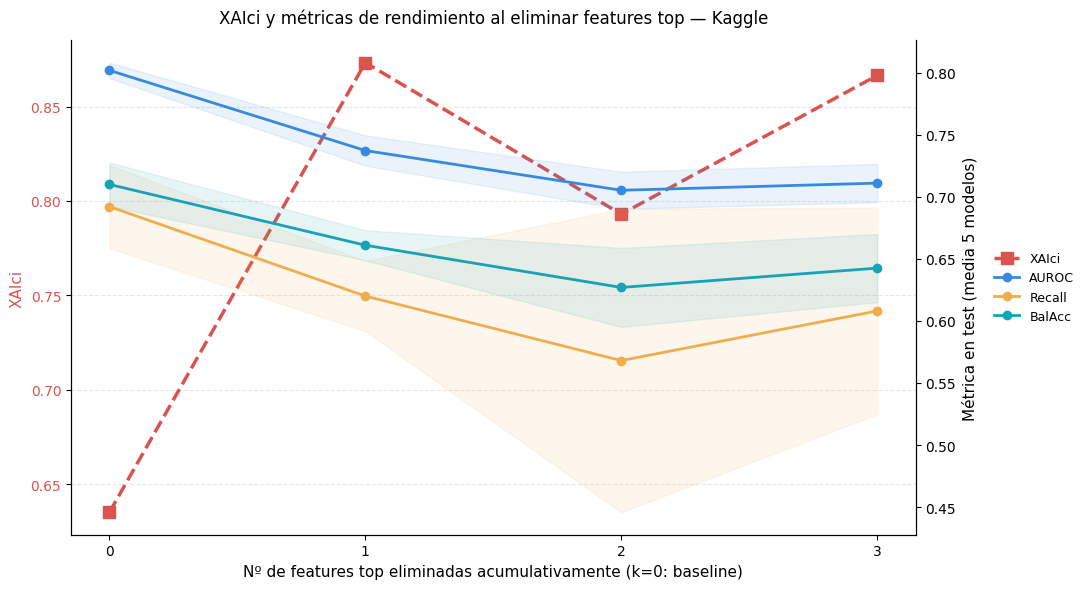

In [ ]:
# ════════════════════════════════════════════════════════════════
#  ABLACIÓN DE LAS TOP-K FEATURES DE XAIqi
# ════════════════════════════════════════════════════════════════

K_DROP = [0, 1, 2, 3]    # k=0: baseline; k=1-3: eliminar top-k

# Modelos originales (para el atajo cuando k=0)
modelos_originales = {
    "rf":  best_rf_under2,
    "xgb": best_xgb_under2,
    "svm": best_svm_under2,
    "lr":  best_lr_under2,
    "nn":  modelo_final_nn_under,
}

# ── Bucle sobre los k a eliminar ──────────────────────────────
resultados_abl = []
for k in K_DROP:
    r = evaluar_ablation(k, xaiqi_df, x_train_UNDER, x_test_final,
                         y_train_UNDER, y_train_under_xgb,
                         y_test_final, y_test_bin,
                         modelos_preentrenados=modelos_originales,
                         xaiqi_original=xaiqi_df,
                         corr_original=corr_df)
    if r is not None:
        resultados_abl.append(r)

# ── Tabla resumen ─────────────────────────────────────────────
resumen_abl = pd.DataFrame([{
    "k_eliminadas":   r["k_drop"],
    "features_fuera": "; ".join(r["dropped"]) if r["dropped"] else "—",
    "n_restantes":    r["n_features"],
    "XAIci":          r["XAIci"],
    **{f"{m}_mean": r[f"{m}_mean"] for m in METRICAS_NOMBRES},
    **{f"{m}_std":  r[f"{m}_std"]  for m in METRICAS_NOMBRES},
} for r in resultados_abl])

print("\n=== RESUMEN ABLATION (XAIci + métricas en test) ===")
cols_display = ["k_eliminadas", "n_restantes", "XAIci"] + \
               [f"{m}_mean" for m in METRICAS_NOMBRES]
print(resumen_abl[cols_display].round(3).to_string(index=False))

# ── Guardado ──────────────────────────────────────────────────
resumen_abl.to_csv(RUTA_BASE + "xaici_metricas_ablation_top.csv", index=False)
for r in resultados_abl:
    k = r["k_drop"]
    r["xaiqi_df"].to_csv(RUTA_BASE + f"xaiqi_drop_top{k}.csv", index=False)
    r["corr_df"].to_csv(RUTA_BASE + f"corr_drop_top{k}.csv",  index=False)

# ── Gráfico: XAIci + métricas al eliminar features ────────────
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(resumen_abl["k_eliminadas"], resumen_abl["XAIci"],
        marker="s", markersize=9, linewidth=2.5,
        color="#D9534F", label="XAIci", linestyle="--")
ax.set_ylabel("XAIci", color="#D9534F", fontsize=11)
ax.tick_params(axis="y", labelcolor="#D9534F")

ax2 = ax.twinx()
colores_met = {
    "AUROC":  "#378ADD",
    "Recall": "#F0AD4E",
    "BalAcc": "#17A2B8",
}
for met, color in colores_met.items():
    ax2.plot(resumen_abl["k_eliminadas"], resumen_abl[f"{met}_mean"],
             marker="o", linewidth=2, color=color, label=met)
    ax2.fill_between(
        resumen_abl["k_eliminadas"],
        resumen_abl[f"{met}_mean"] - resumen_abl[f"{met}_std"],
        resumen_abl[f"{met}_mean"] + resumen_abl[f"{met}_std"],
        color=color, alpha=0.1,
    )

ax2.set_ylabel("Métrica en test (media 5 modelos)", fontsize=11)
ax.set_xlabel("Nº de features top eliminadas acumulativamente (k=0: baseline)",
              fontsize=11)
ax.set_title("XAIci y métricas de rendimiento al eliminar features top — Kaggle",
             fontsize=12, pad=12)
ax.set_xticks(K_DROP)
ax.grid(axis="y", alpha=0.3, linestyle="--")
for s in ["top"]:
    ax.spines[s].set_visible(False)
    ax2.spines[s].set_visible(False)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2,
          loc="center left", bbox_to_anchor=(1.08, 0.5),
          fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

Vemos el reordenamiento de las variables por XAIqi tras eliminar las top - 3 features

Spearman ρ (ranking original vs post-ablación): 0.9121


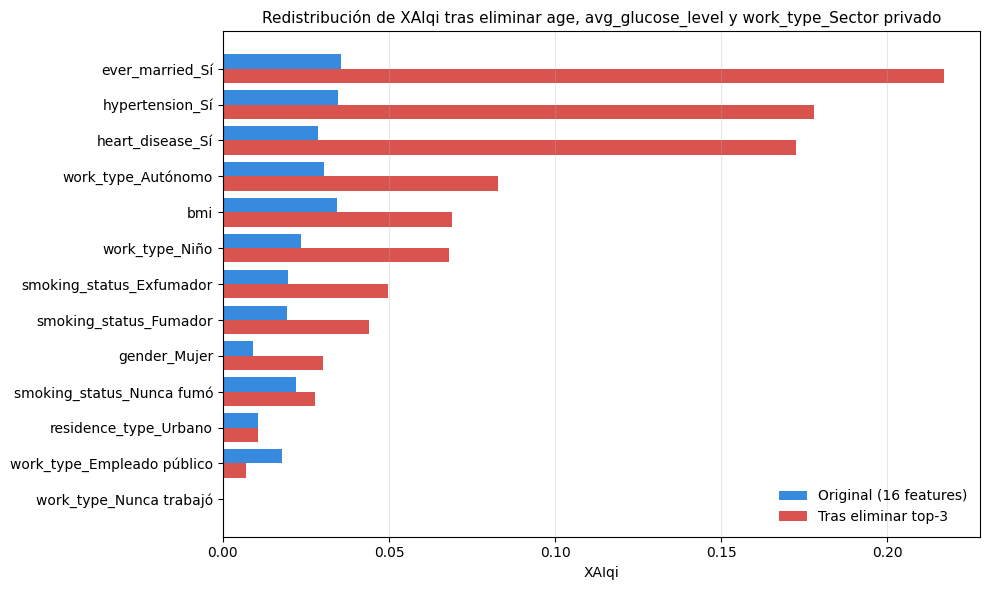

In [ ]:
# ── Cargamos ambos rankings ──────────────────────────────────
xaiqi_orig = pd.read_csv(RUTA_BASE + "xaiqi_features.csv") \
               .sort_values("XAIqi", ascending=False).reset_index(drop=True)
xaiqi_abl  = pd.read_csv(RUTA_BASE + "xaiqi_drop_top3.csv") \
               .sort_values("XAIqi", ascending=False).reset_index(drop=True)

# ── Tabla comparativa ────────────────────────────────────────
comp = xaiqi_orig[["feature", "XAIqi"]].rename(columns={"XAIqi": "XAIqi_orig"}) \
    .merge(xaiqi_abl[["feature", "XAIqi"]].rename(columns={"XAIqi": "XAIqi_abl"}),
           on="feature", how="outer")
comp["delta"] = comp["XAIqi_abl"] - comp["XAIqi_orig"]

# Spearman de estabilidad del ranking (solo features comunes)
common = comp.dropna()
rho, _ = spearmanr(common["XAIqi_orig"], common["XAIqi_abl"])
print(f"Spearman ρ (ranking original vs post-ablación): {rho:.4f}")

# ── Gráfico: top-15 del nuevo ranking, original vs ablación ──
top_feats = xaiqi_abl.head(15)["feature"].tolist()
df = comp.set_index("feature").loc[top_feats].reset_index()

y = range(len(df))
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([i - 0.2 for i in y], df["XAIqi_orig"].fillna(0), 0.4,
        color="#378ADD", label="Original (16 features)")
ax.barh([i + 0.2 for i in y], df["XAIqi_abl"], 0.4,
        color="#D9534F", label="Tras eliminar top-3")

ax.set_yticks(list(y))
ax.set_yticklabels(df["feature"])
ax.invert_yaxis()
ax.set_xlabel("XAIqi")
ax.set_title("Redistribución de XAIqi tras eliminar age, avg_glucose_level y work_type_Sector privado",
             fontsize=11)
ax.legend(loc="lower right", frameon=False)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

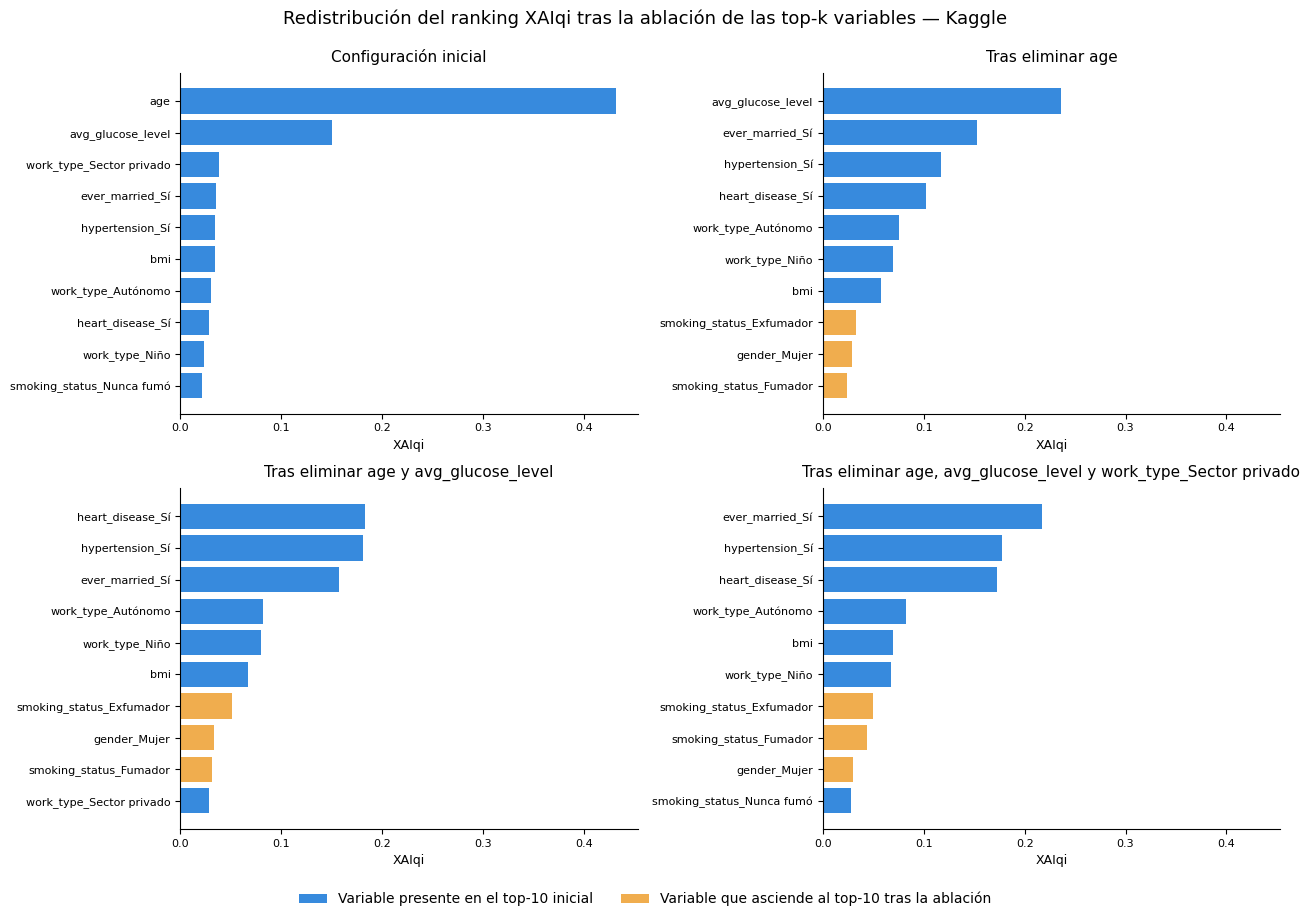

In [ ]:
# ── Configuración ────────────────────────────────────────────
DATASET   = "Kaggle"
K_VALUES  = [0, 1, 2, 3]
TOP_N     = 10

# ── Cargar los rankings de XAIqi por nivel de ablación ───────
xaiqi_dfs = {
    k: (pd.read_csv(RUTA_BASE + f"xaiqi_drop_top{k}.csv")
          .sort_values("XAIqi", ascending=False)
          .head(TOP_N)
          .reset_index(drop=True))
    for k in K_VALUES
}

# Variables que ya formaban parte del top-N en la configuración inicial
baseline_top = set(xaiqi_dfs[0]["feature"])

# ── Escala común ─────────────────────────────────────────────
xmax_global = max(df["XAIqi"].max() for df in xaiqi_dfs.values()) * 1.05

# ── Títulos por panel ────────────────────────────────────────
titulos = {
    0: "Configuración inicial",
    1: "Tras eliminar age",
    2: "Tras eliminar age y avg_glucose_level",
    3: "Tras eliminar age, avg_glucose_level y work_type_Sector privado",
}

# ── Figura: 2×2 ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, k in zip(axes, K_VALUES):
    df = xaiqi_dfs[k]
    colores = ["#378ADD" if f in baseline_top else "#F0AD4E"
               for f in df["feature"]]
    ax.barh(df["feature"], df["XAIqi"], color=colores)
    ax.invert_yaxis()
    ax.set_xlim(0, xmax_global)
    ax.set_xlabel("XAIqi", fontsize=9)
    ax.set_title(titulos[k], pad=8, fontsize=11)
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=8)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)

# Leyenda explicativa del código de colores
legend_elements = [
    Patch(facecolor="#378ADD",
          label="Variable presente en el top-10 inicial"),
    Patch(facecolor="#F0AD4E",
          label="Variable que asciende al top-10 tras la ablación"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=10)

fig.suptitle(
    f"Redistribución del ranking XAIqi tras la ablación de las top-k variables — {DATASET}",
    fontsize=13, y=0.99
)
plt.tight_layout()
plt.subplots_adjust(top=0.92, bottom=0.08)
plt.savefig(RUTA_BASE + f"redistribucion_xaiqi_{DATASET.lower()}.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Análisis por grupos de features

                        grupo        mu     sigma  XAIqi_grupo
0                Demográficas  0.679683  0.097603     0.613344
1  Analíticas/Antropométricas  0.193225  0.068895     0.179913
2                    Clínicas  0.064504  0.030855     0.062514
3              Estilo de vida  0.062587  0.087462     0.057113


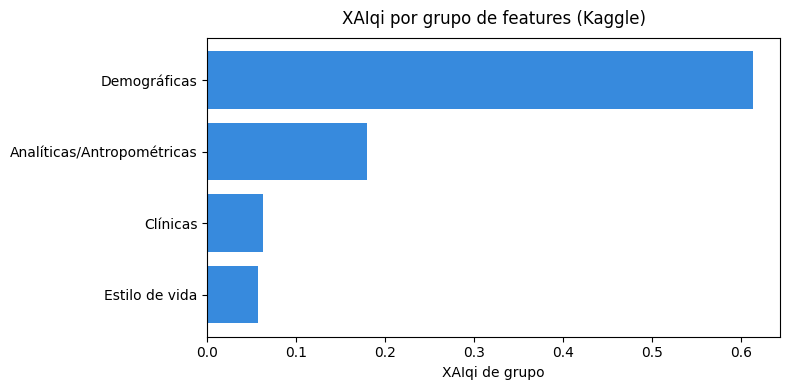

In [ ]:
# ── Diccionario de grupos (Kaggle) ───────────────────────────
grupos = {
    "Demográficas": [
        "age", "gender_Mujer", "ever_married_Sí",
        "residence_type_Urbano",
        "work_type_Sector privado", "work_type_Niño",
        "work_type_Autónomo", "work_type_Empleado público",
        "work_type_Nunca trabajó"
    ],
    "Clínicas": [
        "hypertension_Sí", "heart_disease_Sí"
    ],
    "Estilo de vida": [
        "smoking_status_Nunca fumó", "smoking_status_Exfumador",
        "smoking_status_Fumador"
    ],
    "Analíticas/Antropométricas": [
        "avg_glucose_level", "bmi"
    ]
}

# Guardamos a que grpo pertenece cada feature
feat_to_group = {}
for g, feats in grupos.items():
    for f in feats:
        if f in shap_wide.index: #Solo las features que realmente exiten en el df de XAIqi
            feat_to_group[f] = g

# Comprobamos hemos asignado grupo a todas las variables
huerfanas = [f for f in shap_wide.index if f not in feat_to_group]
if huerfanas:
    print("⚠️  Features sin grupo asignado:", huerfanas)

# Añadimos el grupo a la tabla original como una nueva columna
pivot_grp = shap_wide.copy()
pivot_grp["group"] = pivot_grp.index.map(feat_to_group)
pivot_grp = pivot_grp.dropna(subset=["group"]) #Eliminamos features sin grupo

# Agregamos las features por grupo y sumamos sus SHAP normalizados
group_shap = pivot_grp.groupby("group").sum() #Importancia normalizada de cada grupo por modelo

# Calculamos el XAIqi por grupo siguiendo la misma fórmula
mu_g    = group_shap.mean(axis=1)
sigma_g = group_shap.std(axis=1)
xaiqi_groups = (mu_g * (1 - sigma_g)).sort_values(ascending=False)

#Mostramos la tabla con el XAIqi por grupo
xaiqi_groups_df = pd.DataFrame({
    "grupo": xaiqi_groups.index,
    "mu":    mu_g.loc[xaiqi_groups.index].values,
    "sigma": sigma_g.loc[xaiqi_groups.index].values,
    "XAIqi_grupo": xaiqi_groups.values
}).reset_index(drop=True)
print(xaiqi_groups_df)

# ── Gráfico de barras de XAIqi por grupo ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(xaiqi_groups_df["grupo"], xaiqi_groups_df["XAIqi_grupo"],
        color="#378ADD")
ax.invert_yaxis()
ax.set_xlabel("XAIqi de grupo")
ax.set_title("XAIqi por grupo de features (Kaggle)", pad=10)
plt.tight_layout()
plt.show()

XAIci global (grupos): 0.84
  model  spearman_corr_grupos
0    lr                   1.0
1    rf                   1.0
2   xgb                   1.0
3   svm                   0.8
4    nn                   0.4


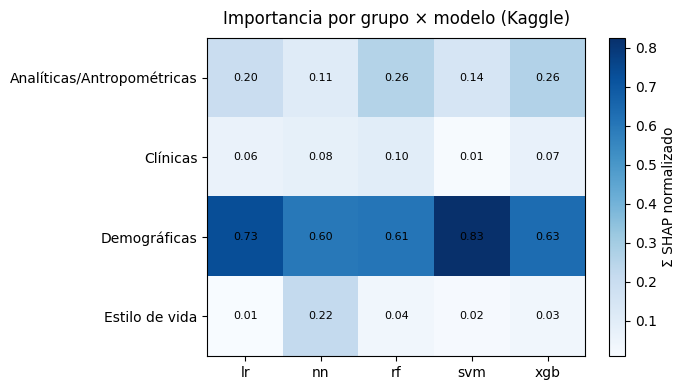

In [ ]:
# ── XAIci a nivel de grupo ────────────────────────────────────
group_sorted = group_shap.loc[xaiqi_groups.index] #ordenamos por XAIqi
xaiqi_values_g = xaiqi_groups.values

#Calculamos la correlación por modelo
corrs_g = {}
for m in group_shap.columns:
    rho, _ = spearmanr(group_sorted[m].values, xaiqi_values_g)
    corrs_g[m] = rho

#Tabla de correlaciones
corr_groups_df = pd.DataFrame({
    "model": corrs_g.keys(),
    "spearman_corr_grupos": corrs_g.values()
}).sort_values("spearman_corr_grupos", ascending=False).reset_index(drop=True)

#Calculamos el valor de XAIci global
XAIci_groups = corr_groups_df["spearman_corr_grupos"].mean()
print(f"XAIci global (grupos): {round(XAIci_groups, 4)}")
print(corr_groups_df)

# ── Heatmap de grupos × modelo ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(group_shap.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(len(group_shap.columns)))
ax.set_xticklabels(group_shap.columns)
ax.set_yticks(range(len(group_shap.index)))
ax.set_yticklabels(group_shap.index)
for i in range(group_shap.shape[0]):
    for j in range(group_shap.shape[1]):
        ax.text(j, i, f"{group_shap.values[i,j]:.2f}",
                ha="center", va="center", color="black", fontsize=8)
plt.colorbar(im, ax=ax, label="Σ SHAP normalizado")
ax.set_title("Importancia por grupo × modelo (Kaggle)", pad=10)
plt.tight_layout()
plt.show()

##Leave-One-Out de modelos

LOO de modelos (XAIci_base = 0.6352 )
  modelo_excluido  XAIci_sin_el  delta_vs_base
0             svm      0.728900       0.093719
1              nn      0.692540       0.057359
2              lr      0.657458       0.022277
3             xgb      0.649221       0.014040
4              rf      0.609118      -0.026063


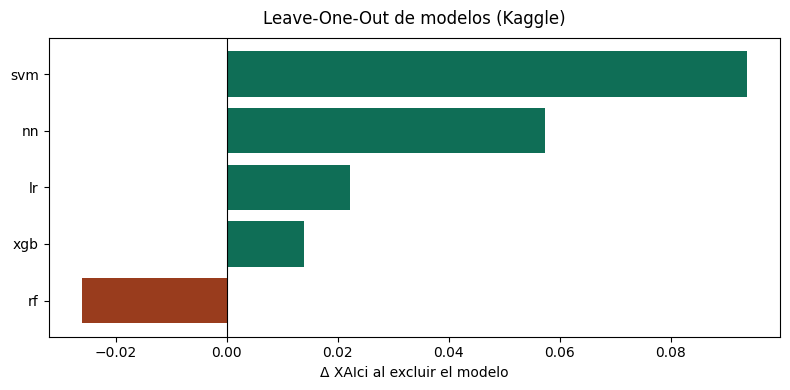

In [ ]:
#Guardamos todos los modelos empleados
modelos_all = list(shap_wide.columns)
loo_modelos = []

# Valor de XAIci global usando todos los modelos
XAIci_base = corr_df["spearman_corr"].mean()

#Creamos un loop para ir quitando un modelo cada vez
for m_out in modelos_all:
    modelos_sub = [m for m in modelos_all if m != m_out] #Subconjunto sin un modelo

    # Recalculamos XAIqi solo con el subset de modelos
    shap_wide_sub = shap_wide[modelos_sub]
    mu_s    = shap_wide_sub.mean(axis=1)
    sigma_s = shap_wide_sub.std(axis=1)
    xaiqi_s = (mu_s * (1 - sigma_s))

    # Recalculamos Spearman de cada modelo restante contra el nuevo XAIqi
    order       = xaiqi_s.sort_values(ascending=False).index #ordenamos features por XAIqi
    xaiqi_vals  = xaiqi_s.loc[order].values
    shap_wide_ord   = shap_wide_sub.loc[order]

    #Calculamos correlaciones para los modelos restantes
    corrs = []
    for m in modelos_sub:
        rho, _ = spearmanr(shap_wide_ord[m].values, xaiqi_vals)
        corrs.append(rho)

    loo_modelos.append({
        "modelo_excluido": m_out,
        "XAIci_sin_el":   np.mean(corrs),
        "delta_vs_base":   np.mean(corrs) - XAIci_base #Comparamos con XAIci global
    })

#Guardamos los resultados ordenados por impacto
loo_modelos_df = pd.DataFrame(loo_modelos).sort_values(
    "delta_vs_base", ascending=False
).reset_index(drop=True)
print("LOO de modelos (XAIci_base =", round(XAIci_base, 4), ")")
print(loo_modelos_df)

# Gráfico
fig, ax = plt.subplots(figsize=(8, 4))
colors_loo = ["#0F6E56" if d >= 0 else "#993C1D"
              for d in loo_modelos_df["delta_vs_base"]]
ax.barh(loo_modelos_df["modelo_excluido"],
        loo_modelos_df["delta_vs_base"], color=colors_loo)
ax.axvline(0, color="black", linewidth=0.8)
ax.invert_yaxis()
ax.set_xlabel("Δ XAIci al excluir el modelo")
ax.set_title("Leave-One-Out de modelos (Kaggle)", pad=10)
plt.tight_layout()
plt.show()

## Comparación entre tipos de modelos

XAIci base (5 modelos): 0.6352

=== A. Consenso intra-grupo ===
       grupo  n_modelos     modelos  XAIci_intra
   Arbolados          2     rf, xgb     0.989706
No arbolados          3 svm, lr, nn     0.686795

=== B. Leave-group-out ===
grupo_excluido modelos_usados  XAIci_sin_grupo  delta_vs_base
     Arbolados    lr, nn, svm         0.686795       0.051613
  No arbolados        rf, xgb         0.989706       0.354525


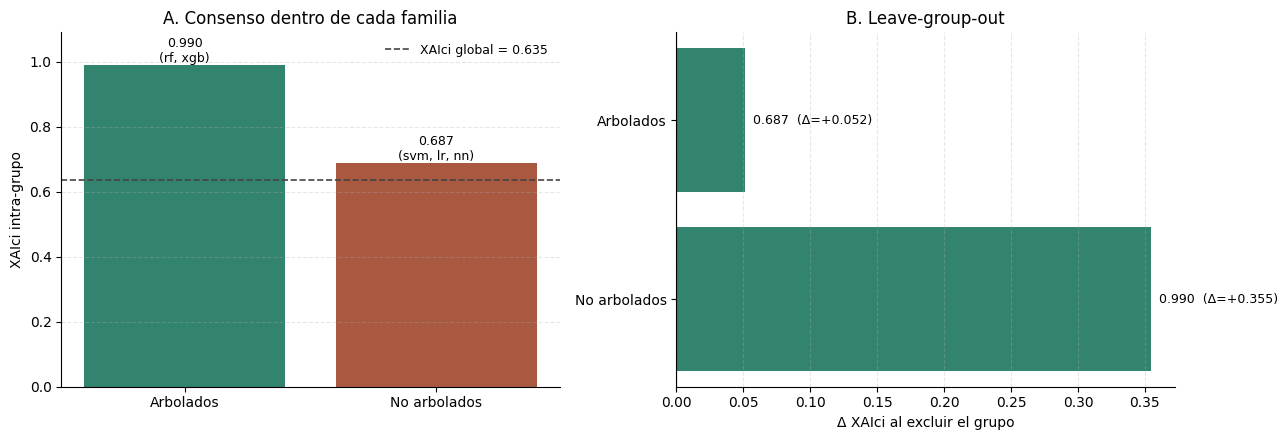

In [ ]:
# ── Grupos ───────────────────────────────────────────────────
grupos = {
    "Arbolados":     ["rf", "xgb"],
    "No arbolados":  ["svm", "lr", "nn"],
}


# Función auxiliar: XAIci dado un subconjunto de modelos
def xaici_de(modelos_subset, shap_wide):
    sub = shap_wide[modelos_subset]
    mu, sigma = sub.mean(axis=1), sub.std(axis=1)
    xaiqi = (mu * (1 - sigma)).sort_values(ascending=False)
    sub_ord = sub.loc[xaiqi.index]
    corrs = [spearmanr(sub_ord[m].values, xaiqi.values)[0]
             for m in modelos_subset]
    return float(np.nanmean(corrs))


# ── Análisis A: XAIci intra-grupo ────────────────────────────
XAIci_base = corr_df["spearman_corr"].mean()

intra = []
for nombre, modelos in grupos.items():
    intra.append({
        "grupo":         nombre,
        "n_modelos":     len(modelos),
        "modelos":       ", ".join(modelos),
        "XAIci_intra":   xaici_de(modelos, shap_wide),
    })
intra_df = pd.DataFrame(intra)


# ── Análisis B: leave-group-out ──────────────────────────────
lgo = []
todos = list(shap_wide.columns)
for nombre, modelos in grupos.items():
    restantes = [m for m in todos if m not in modelos]
    xaici_sin = xaici_de(restantes, shap_wide)
    lgo.append({
        "grupo_excluido": nombre,
        "modelos_usados": ", ".join(restantes),
        "XAIci_sin_grupo": xaici_sin,
        "delta_vs_base":   xaici_sin - XAIci_base,
    })
lgo_df = pd.DataFrame(lgo)

print(f"XAIci base (5 modelos): {XAIci_base:.4f}\n")
print("=== A. Consenso intra-grupo ===")
print(intra_df.to_string(index=False))
print("\n=== B. Leave-group-out ===")
print(lgo_df.to_string(index=False))


# ── Gráfico conjunto ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel A: barras intra-grupo + línea base
colors_a = ["#0F6E56", "#993C1D"]
ax1.bar(intra_df["grupo"], intra_df["XAIci_intra"],
        color=colors_a, alpha=0.85)
ax1.axhline(XAIci_base, color="#444", linestyle="--", linewidth=1.2,
            label=f"XAIci global = {XAIci_base:.3f}")
for i, row in intra_df.iterrows():
    ax1.text(i, row["XAIci_intra"] + 0.01,
             f"{row['XAIci_intra']:.3f}\n({row['modelos']})",
             ha="center", fontsize=9)
ax1.set_ylabel("XAIci intra-grupo")
ax1.set_title("A. Consenso dentro de cada familia")
ax1.set_ylim(0, max(1.0, intra_df["XAIci_intra"].max() + 0.1))
ax1.legend(frameon=False, fontsize=9)
ax1.grid(axis="y", alpha=0.3, linestyle="--")
for s in ["top", "right"]:
    ax1.spines[s].set_visible(False)

# Panel B: leave-group-out (delta vs base)
colors_b = ["#0F6E56" if d >= 0 else "#993C1D"
            for d in lgo_df["delta_vs_base"]]
ax2.barh(lgo_df["grupo_excluido"], lgo_df["delta_vs_base"],
         color=colors_b, alpha=0.85)
ax2.axvline(0, color="black", linewidth=0.8)
for i, row in lgo_df.iterrows():
    ax2.text(row["delta_vs_base"], i,
             f"  {row['XAIci_sin_grupo']:.3f}  (Δ={row['delta_vs_base']:+.3f})",
             va="center",
             ha="left" if row["delta_vs_base"] >= 0 else "right",
             fontsize=9)
ax2.invert_yaxis()
ax2.set_xlabel("Δ XAIci al excluir el grupo")
ax2.set_title("B. Leave-group-out")
ax2.grid(axis="x", alpha=0.3, linestyle="--")
for s in ["top", "right"]:
    ax2.spines[s].set_visible(False)

plt.tight_layout()
plt.show()